<a href="https://colab.research.google.com/github/ericiortega/aipi590-xai-fall2025/blob/main/assignments/mechanistic_interpretability/mechanistic_interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mechanistic Interpretability: Explaining a Tiny Brain

**Course:** AIPI 590 – Emerging Trends in Explainable AI (Fall 2025)  
**Professor:** Dr. Brinnae Bent  
**Author:** Eric Ortega Rodriguez  
**Case Domain:** Mechanistic Interpretability & Neural Understanding  
**Assigned Task:** Build, train, and interpret a tiny neural network to uncover what one neuron or component is “thinking.”  
**Deadline:** November 14, 2025 @ 11:30 AM  
**GitHub Repo:** [Assignment Folder](https://github.com/ericiortega/aipi590-xai-fall2025/tree/main/assignments/mechanistic_interpretability)  

## Introduction

In this notebook, I explore the concept of mechanistic interpretability. I will do this by training a tiny neural network on a simple task and analyzing how its internal components (like neurons, activations, and weights) represent underlying meaningful logic.

The goal is to identify one interpretable neuron or feature that exhibits a clear and explainable pattern.

In [16]:
# Importing libraries (Based on Dr. Bent's Colab Notebook)
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import numpy as np

## Part 1 – Setup (Train My Own Tiny Model on a Tiny Task)

In [17]:
# Setting seeds so it is reproducible
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

In [18]:
# Generate Toy Dataset (Dr. Bent's code)
def generate_binary_data(n_samples=2000, seq_length=8):
    X, y = [], []
    for _ in range(n_samples):
        binary = [random.choice([0, 1]) for _ in range(seq_length)]
        label = sum(binary)
        X.append(binary)
        y.append(label)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

seq_length = 8
n_classes = seq_length + 1
X_train, y_train = generate_binary_data(2000, seq_length)
X_val, y_val = generate_binary_data(500, seq_length)


In [19]:
# Updated Model for Regression (From Dr. Bent)
class CountingMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)  # Output is a single scalar

    def forward(self, x):
        h = F.relu(self.fc1(x))
        out = self.fc2(h)
        return out, h  # for interpretability

# Instantiate model
model = CountingMLP(input_dim=seq_length, hidden_dim=10)
print(model)

# Convert targets to float (regression labels)
y_train_reg = y_train.float().unsqueeze(1)
y_val_reg = y_val.float().unsqueeze(1)

# Training loop with MSE loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

losses = []
for epoch in range(100):
    model.train()
    out, _ = model(X_train)
    loss = criterion(out, y_train_reg)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print("Final training loss:", losses[-1])

CountingMLP(
  (fc1): Linear(in_features=8, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=1, bias=True)
)
Final training loss: 0.11327363550662994


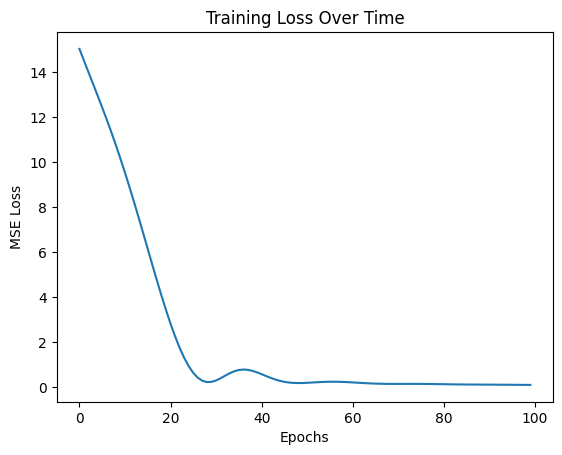

In [20]:
# adding visualization to the see the traiing loss over time
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training Loss Over Time")
plt.show()


The training loss decreases rapidly during the first 30 to 40 epochs and then levels off close to zero. This shows us that the model quickly learned to predict the number of 1s and converged to a stable solution without overfitting.

In [21]:
# Evaluation: Mean Absolute Error + Rounded Accuracy (From Dr. Bent)
model.eval()
with torch.no_grad():
    preds, _ = model(X_val)
    mae = torch.abs(preds - y_val_reg).mean().item()
    rounded_preds = torch.round(preds).squeeze().long()
    accuracy = (rounded_preds == y_val).float().mean().item()

print(f"Validation MAE: {mae:.2f}")
print(f"Rounded Accuracy: {accuracy:.2f}")

Validation MAE: 0.27
Rounded Accuracy: 0.85


In [22]:
with torch.no_grad():
    preds, _ = model(X_val[:5])
for x, y_true, y_hat in zip(X_val[:5], y_val[:5], preds.squeeze()):
    print(x.int().tolist(), " | true:", int(y_true), " pred:", round(float(y_hat), 2))

[0, 1, 1, 1, 0, 0, 1, 0]  | true: 4  pred: 3.99
[1, 0, 1, 0, 0, 1, 0, 0]  | true: 3  pred: 3.28
[0, 1, 1, 1, 1, 1, 1, 1]  | true: 7  pred: 6.4
[0, 1, 1, 1, 1, 1, 1, 0]  | true: 6  pred: 5.54
[0, 0, 0, 1, 0, 1, 1, 1]  | true: 4  pred: 4.12


These sample predictions show that the model has learned to count accurately. For each 8-bit sequence, the predicted number of 1s is very close to the true value(less than one count)

## Part 2 – Explore
The objective here is to actually look within the model and see how it is solving our problem.

### Weight exploration

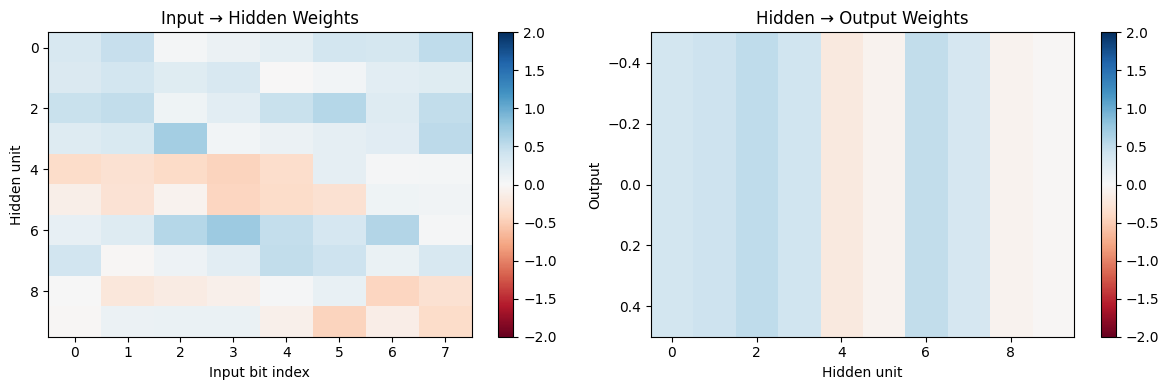

In [29]:
#Weight Magnitude & Direction Across Layers
with torch.no_grad():
    fc1_w = model.fc1.weight.detach().cpu().numpy()   # [n_hidden, 8]
    fc2_w = model.fc2.weight.detach().cpu().numpy()   # [1, n_hidden]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im1 = axes[0].imshow(fc1_w, aspect="auto", cmap="RdBu", vmin=-2, vmax=2)
axes[0].set_title("Input → Hidden Weights")
axes[0].set_xlabel("Input bit index"); axes[0].set_ylabel("Hidden unit")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(fc2_w, aspect="auto", cmap="RdBu", vmin=-2, vmax=2)
axes[1].set_title("Hidden → Output Weights")
axes[1].set_xlabel("Hidden unit"); axes[1].set_ylabel("Output")
plt.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.show()


### Correlation Between Hidden Unit Activation and Input Count

In [25]:
corrs = []
for i in range(n_hidden):
    a = avg_acts[:, i].numpy()
    k_vals = np.arange(seq_length + 1)
    # guard against constant activation
    if a.std() == 0:
        c = np.nan
    else:
        c = np.corrcoef(a, k_vals)[0, 1]
    corrs.append(c)
    print(f"Hidden {i}: corr with count = {c:+.3f}")


Hidden 0: corr with count = +0.999
Hidden 1: corr with count = +0.975
Hidden 2: corr with count = +0.993
Hidden 3: corr with count = +0.998
Hidden 4: corr with count = -0.566
Hidden 5: corr with count = +nan
Hidden 6: corr with count = +0.999
Hidden 7: corr with count = +0.999
Hidden 8: corr with count = -0.570
Hidden 9: corr with count = -0.137


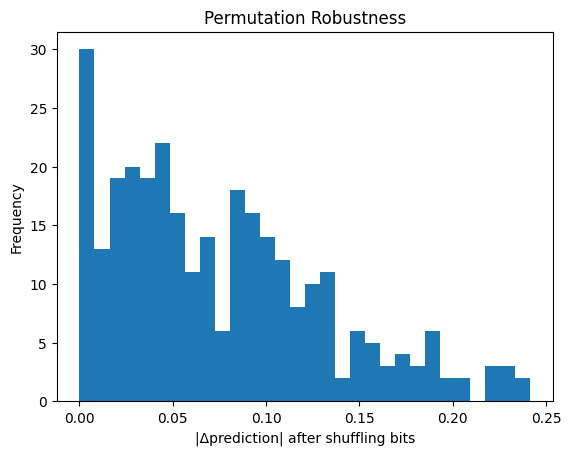

In [28]:
model.eval()
diffs = []
with torch.no_grad():
    for x in X_val[:300]:
        x = x.unsqueeze(0)
        y1, _ = model(x)
        perm = x[:, torch.randperm(x.size(1))]      # shuffle bit order
        y2, _ = model(perm)
        diffs.append(float((y1 - y2).abs()))
plt.hist(diffs, bins=30)
plt.xlabel("prediction after shuffling bits")
plt.ylabel("Frequency")
plt.title("Permutation Robustness")
plt.show()


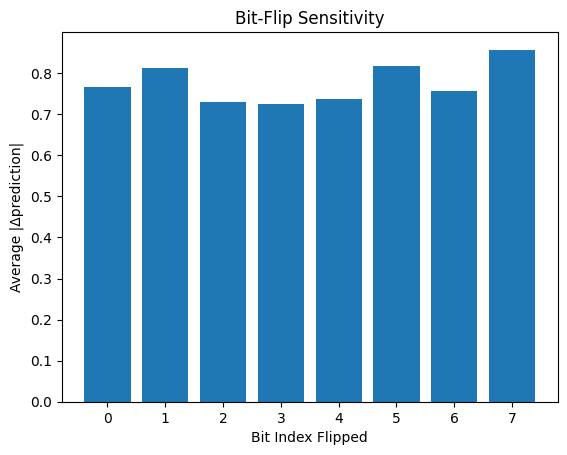

In [27]:
# Bit-Flip Sensitivity Test (Fixed)
import torch
import matplotlib.pyplot as plt

# Get baseline predictions
model.eval()
with torch.no_grad():
    base_pred, _ = model(X_val)
base_pred = base_pred.squeeze()

# Store average change in prediction for each bit position
flip_effects = torch.zeros(X_val.shape[1])

with torch.no_grad():  # ensures no gradients are tracked
    for j in range(X_val.shape[1]):
        X_flip = X_val.clone()
        X_flip[:, j] = 1 - X_flip[:, j]  # flip bit j
        y_flip, _ = model(X_flip)
        flip_effects[j] = (y_flip.squeeze() - base_pred).abs().mean()

# Convert to numpy safely for plotting
flip_effects_np = flip_effects.detach().numpy()

# Plot
plt.bar(range(len(flip_effects_np)), flip_effects_np)
plt.xlabel("Bit Index Flipped")
plt.ylabel("Average prediction")
plt.title("Bit-Flip Sensitivity")
plt.show()


## Part 3 – Explain

Through the exploration above, I found that hidden units in my network correlate with the number of 1s in my input.

## Part 4 – Reflect